In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

df = pd.read_csv("MachineLearningRating_v3.txt", sep="|", engine="python", on_bad_lines='warn')

In [2]:
df.isnull().sum()

UnderwrittenCoverID               0
PolicyID                          0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
LegalType                         0
Title                             0
Language                          0
Bank                         145961
AccountType                   40232
MaritalStatus                  8259
Gender                         9536
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                          552
VehicleType                     552
RegistrationYear                  0
make                            552
Model                           552
Cylinders                       552
cubiccapacity                   552
kilowatts                       552
bodytype                        552
NumberOfDoors               

In [7]:
df.dtypes

UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[ns]
IsVATRegistered                       bool
Citizenship                       category
LegalType                         category
Title                             category
Language                          category
Bank                              category
AccountType                       category
MaritalStatus                     category
Gender                            category
Country                           category
Province                          category
PostalCode                        category
MainCrestaZone                    category
SubCrestaZone                     category
ItemType                          category
mmcode                             float64
VehicleType                       category
RegistrationYear                     int64
make                              category
Model                             category
Cylinders  

In [4]:
#Cleaning data

# Drop null 'Bank' and 'AccountType' rows
df = df.dropna(subset=['Bank', 'AccountType'])

# Drop the column NumberOfVehiclesInFleet cause all values are Nan
df = df.drop(columns=['NumberOfVehiclesInFleet'])

# Drop negative TotalClaim values
df = df[df['TotalClaims'] >= 0]
df = df[df['TotalPremium'] >= 0]

# Replace missing values with 'Unknown' 
unknown_columns = ['Gender', 'MaritalStatus', 'VehicleType', 'make', 'Model', 'mmcode']
for col in unknown_columns:
    df[col].fillna('Unknown')

# Replace missing values with median 
median_columns = ['Cylinders', 'cubiccapacity']
for col in median_columns:
    df[col].fillna(df[col].median())
    

In [5]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

categorical_cols = [
    'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType',
    'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode',
    'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make',
    'Model', 'bodytype', 'TermFrequency', 'ExcessSelected', 'CoverCategory',
    'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass',
    'StatutoryRiskType'
]

df[categorical_cols] = df[categorical_cols].astype('category')


Data Summarization

In [60]:
numeric_col = ['TotalClaims', 'TotalPremium']

variability_stats = df[numeric_col].agg(['mean', 'std', 'var', 'min', 'max', 'median', 'quantile'])

Q1 = df[numeric_col].quantile(0.25)
Q3 = df[numeric_col].quantile(0.75)
IQR = Q3 - Q1

var_df = pd.DataFrame({
    'mean' : df[numeric_col].mean(),
    'std' : df[numeric_col].std(),
    'var' : df[numeric_col].var(),
    'min' : df[numeric_col].min(),
    'max' : df[numeric_col].max(),
    'range' : df[numeric_col].max() - df[numeric_col].min(),
    'IQR' : IQR,
})

var_df


,mean,std,var,min,max,range,IQR
TotalClaims,69.413138,2434.123662,5.924958e+06,0.000000,393092.105263,393092.105263,0.000000
TotalPremium,61.070795,239.461693,5.734190e+04,-782.576754,65282.603421,66065.180175,21.929825


Univariate Analysis

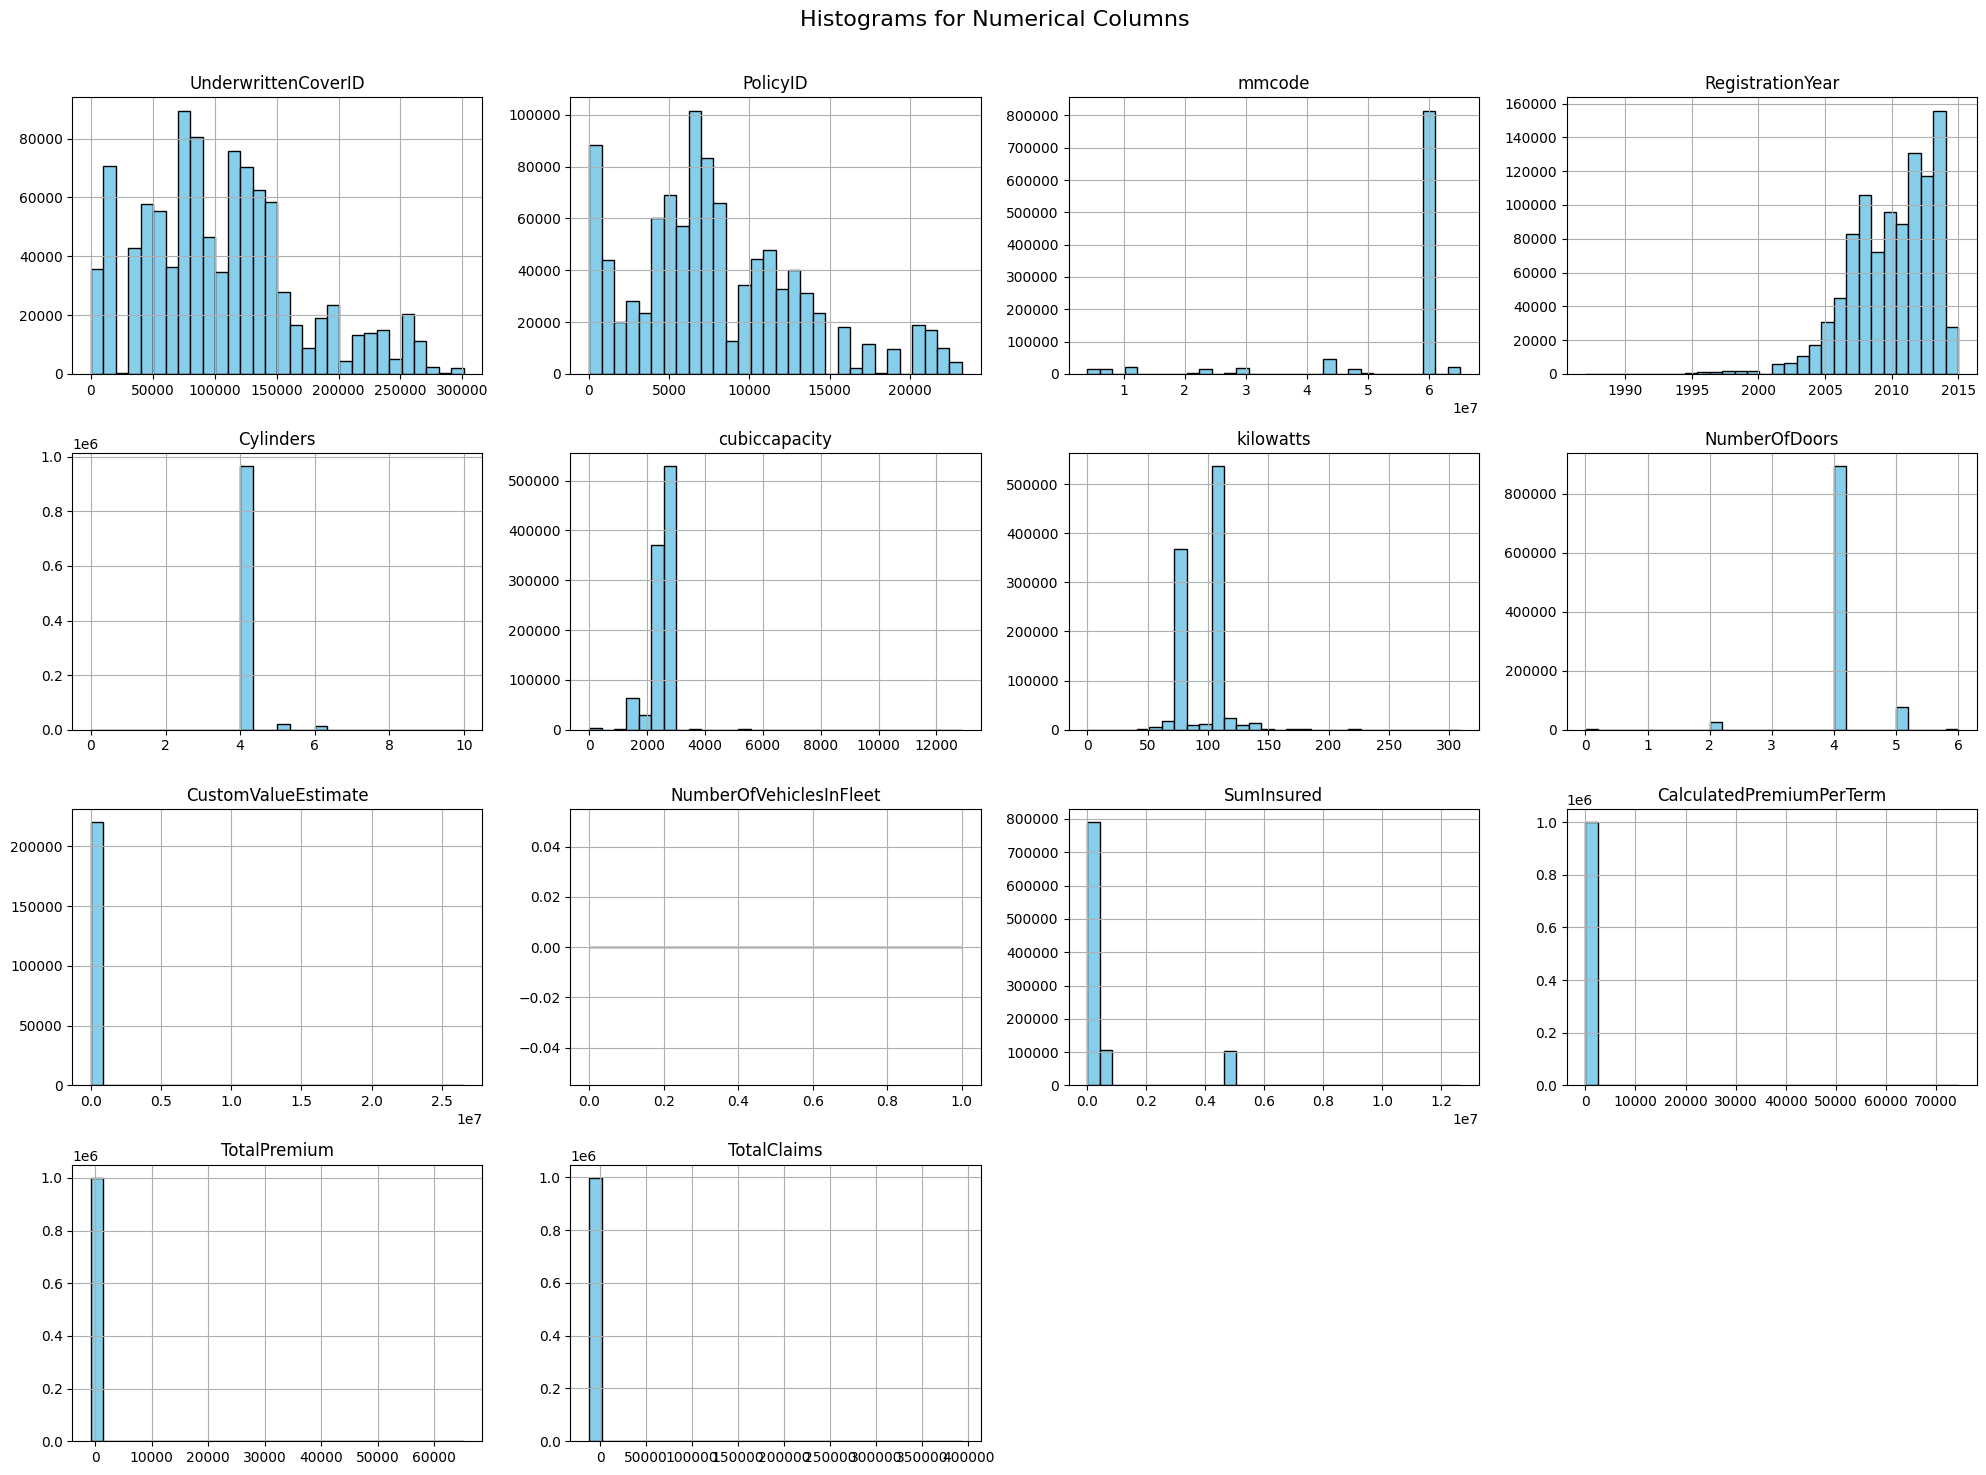

In [13]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=30, figsize=(20, 15), layout=(len(numeric_cols)//4+1, 4), color='skyblue', edgecolor='black')
plt.suptitle("Histograms for Numerical Columns", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


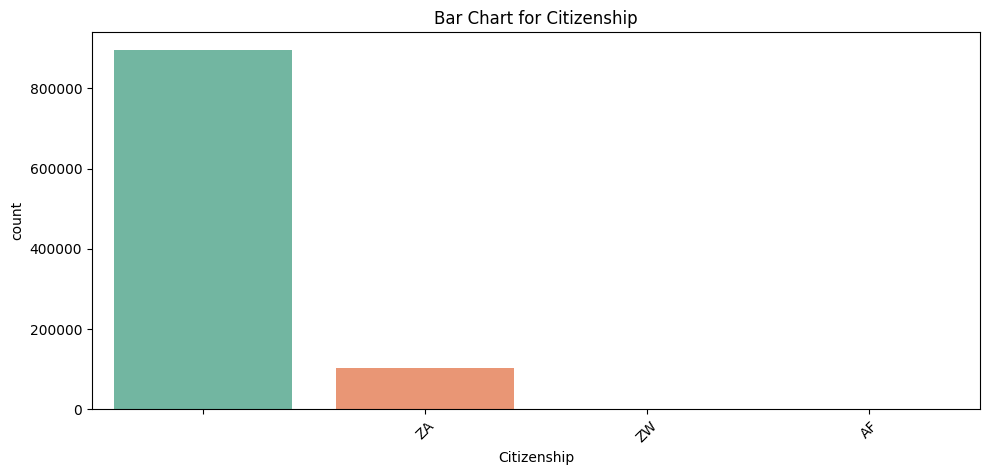

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


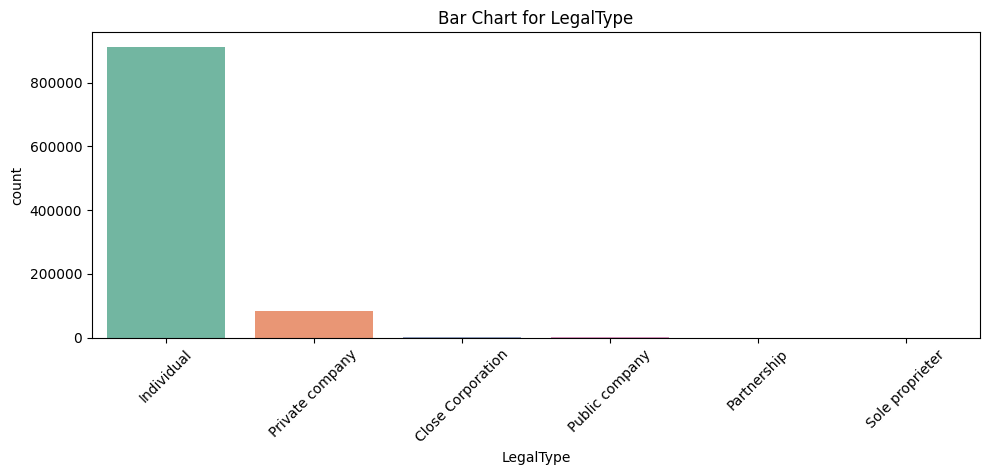

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


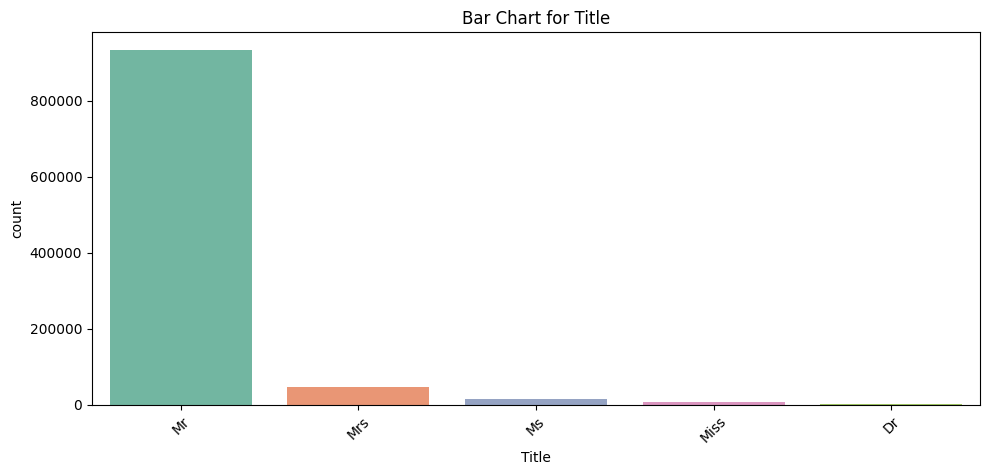

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


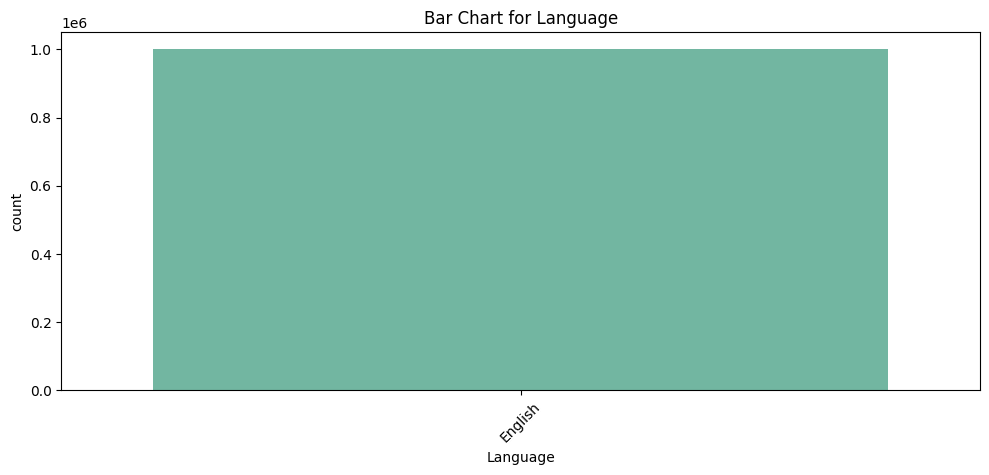

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


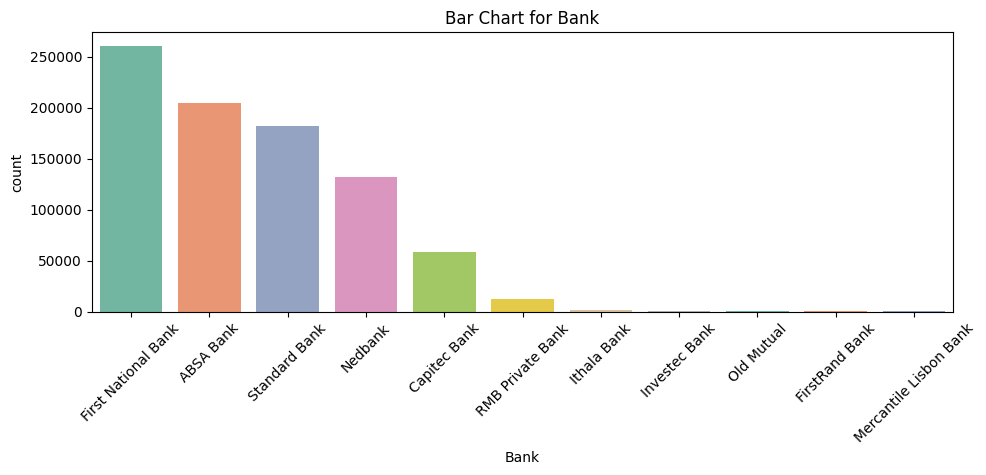

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


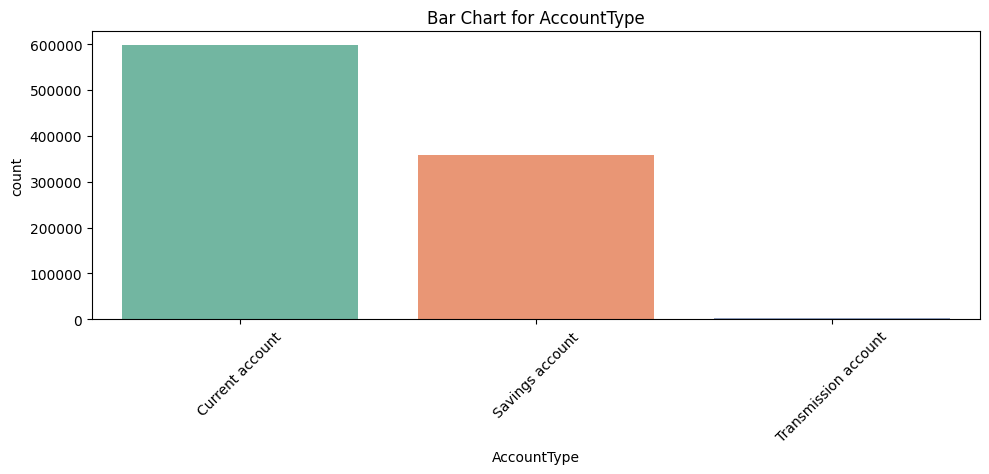

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


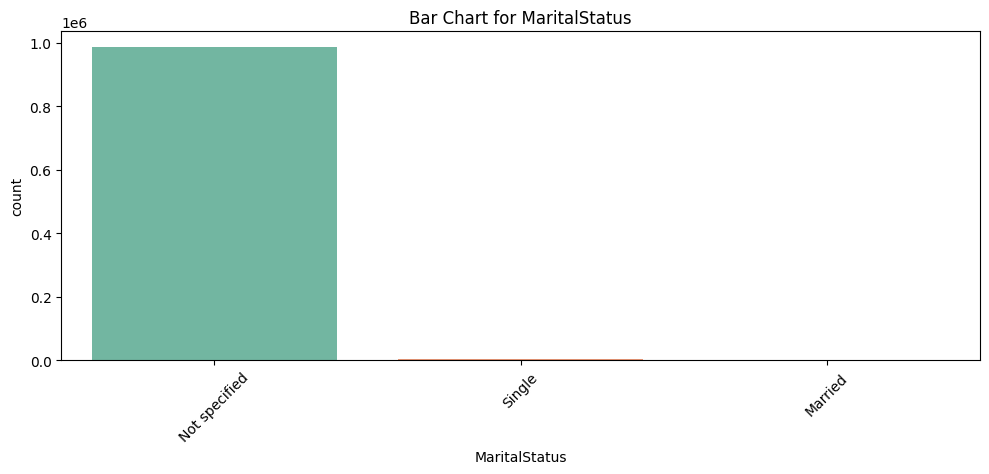

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


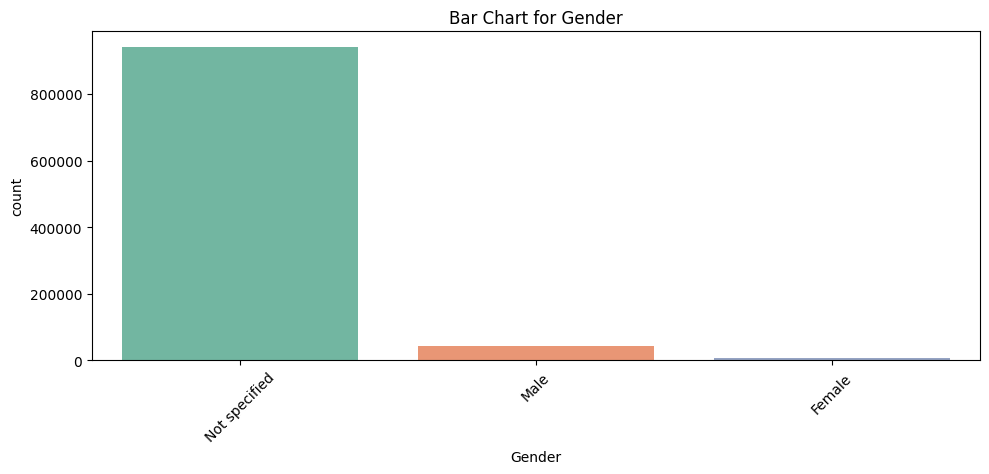

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


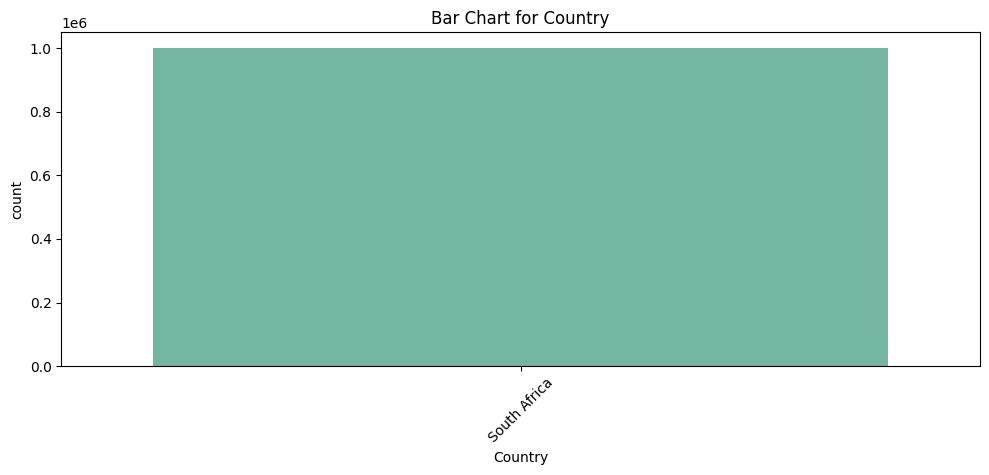

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


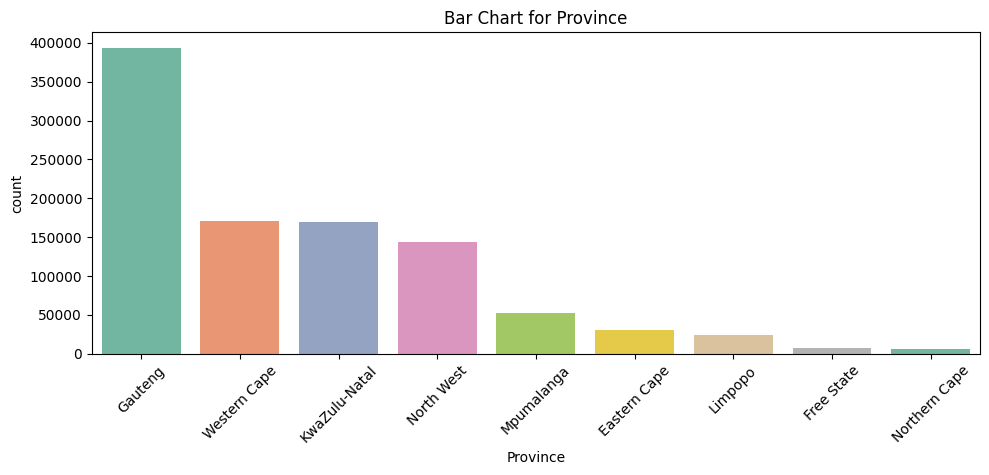

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


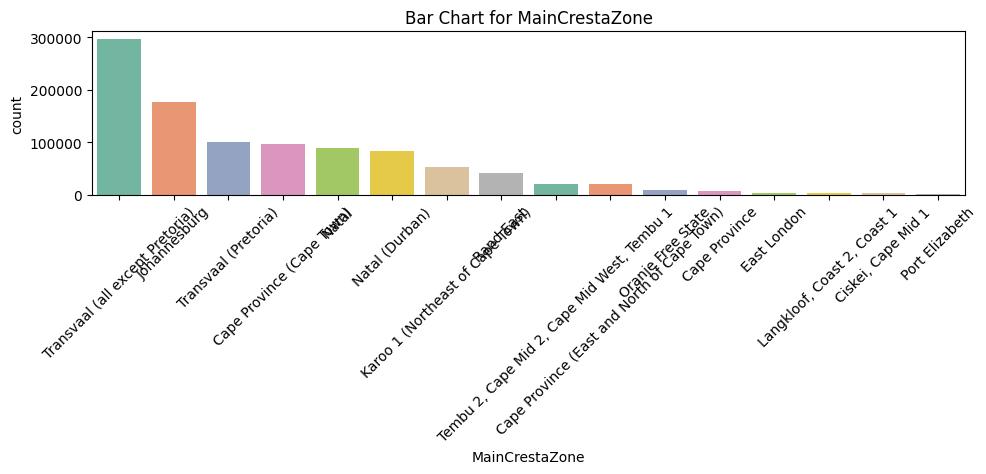

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


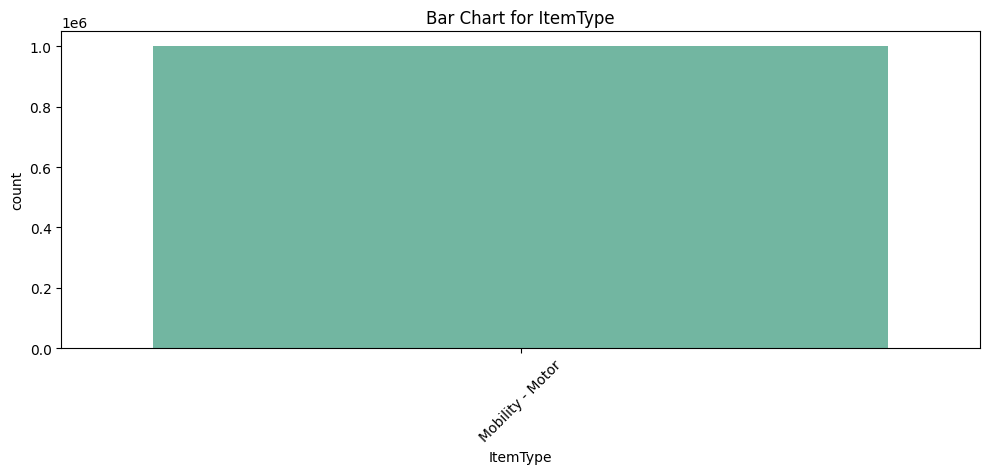

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


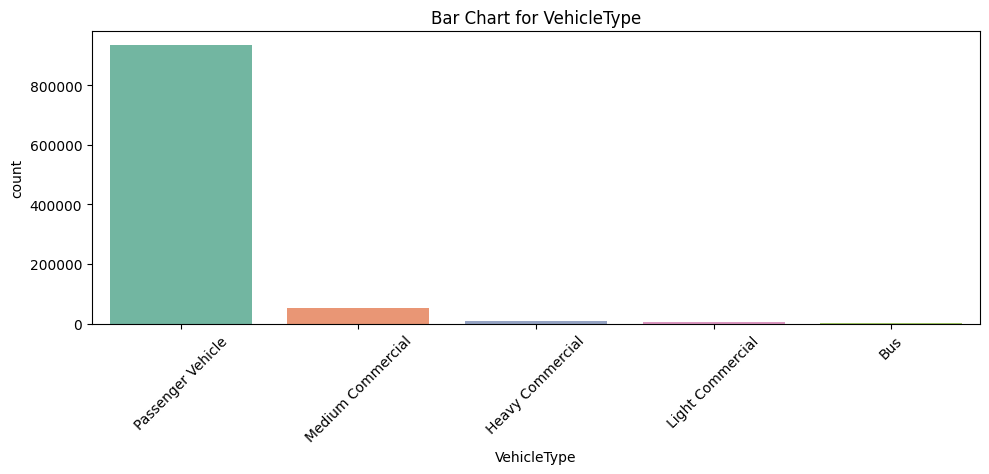

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


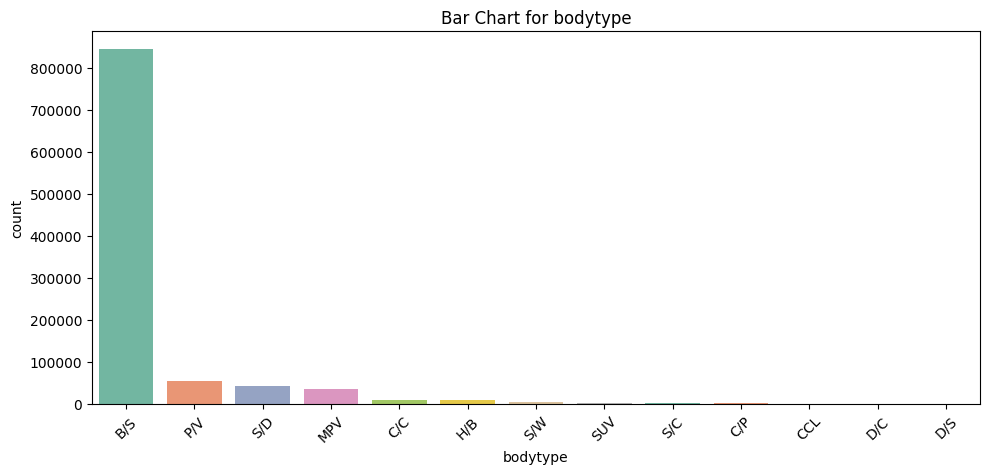

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


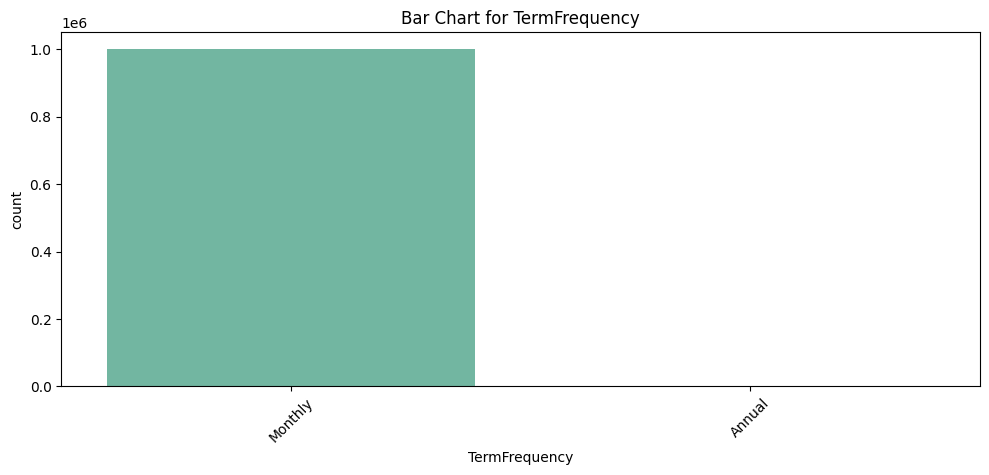

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


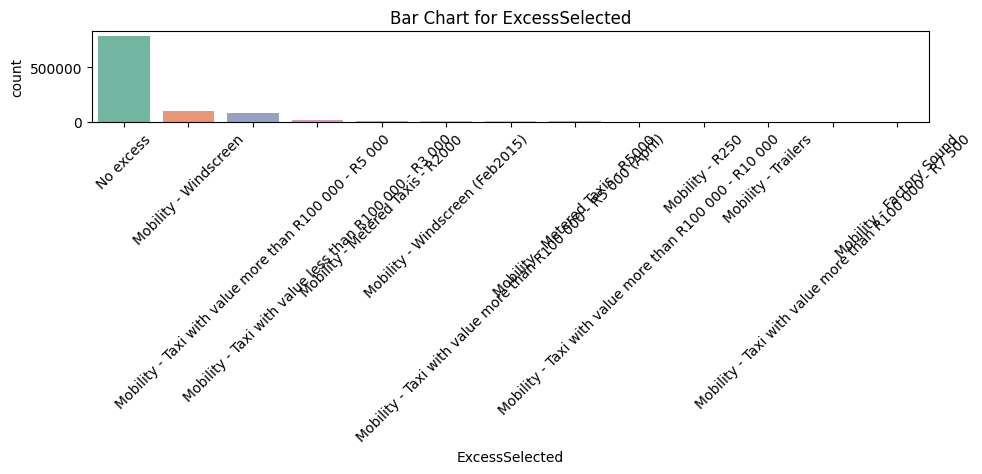

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


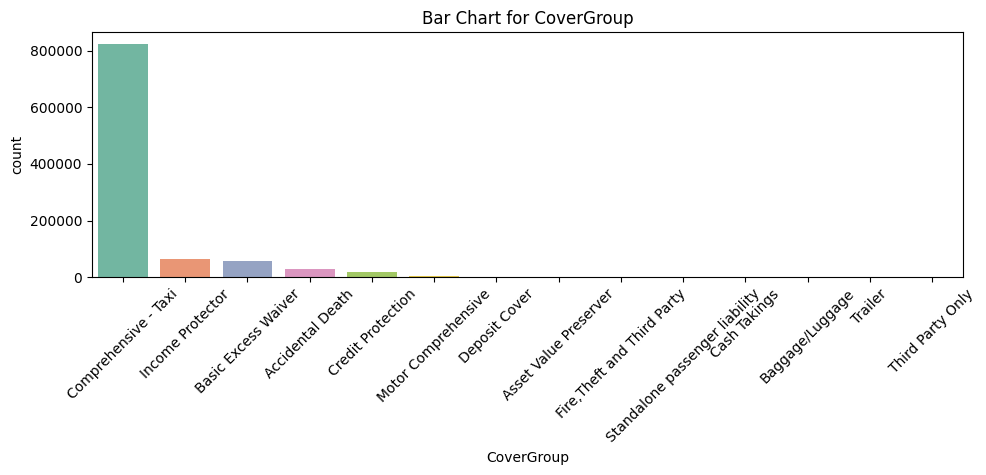

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


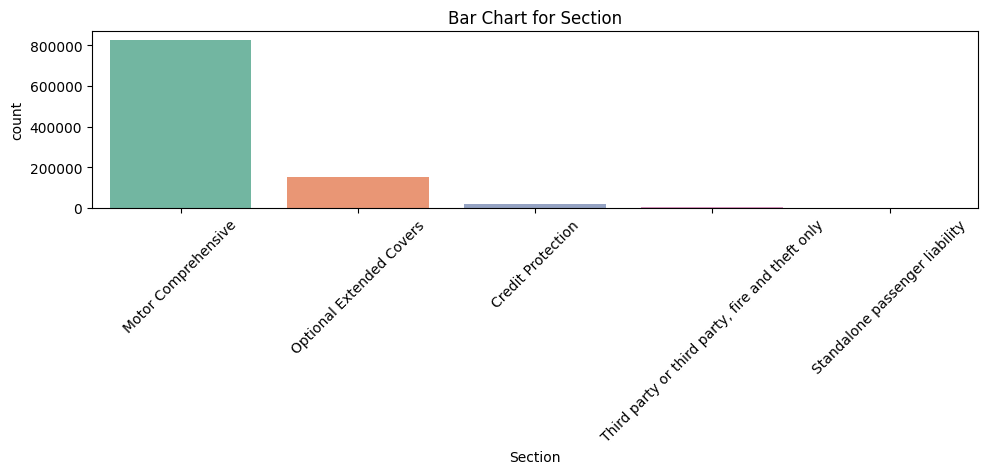

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


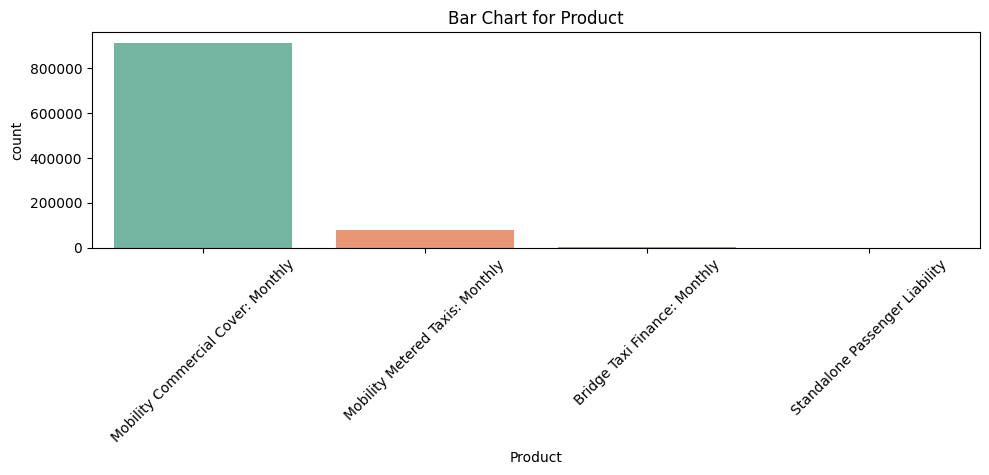

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


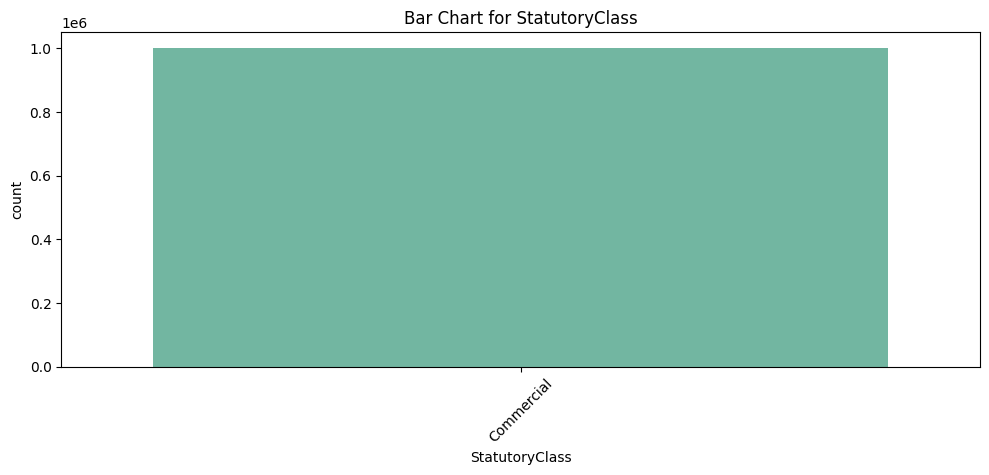

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\2877375826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)


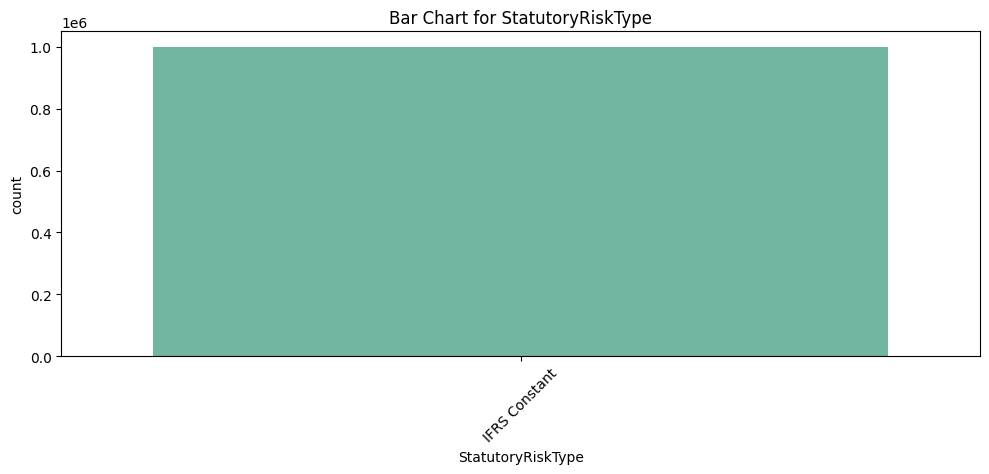

In [27]:
# Select categorical columns
cat_cols = df.select_dtypes(include='category').columns

# Filter to only categorical columns with few unique values (to keep plots readable)
cat_cols_few = [col for col in cat_cols if df[col].nunique() <= 20]


# Plot bar charts
for col in cat_cols_few:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)
    plt.title(f'Bar Chart for {col}')
    plt.xticks(rotation=45)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


Bivariate or Multivariate Analysis

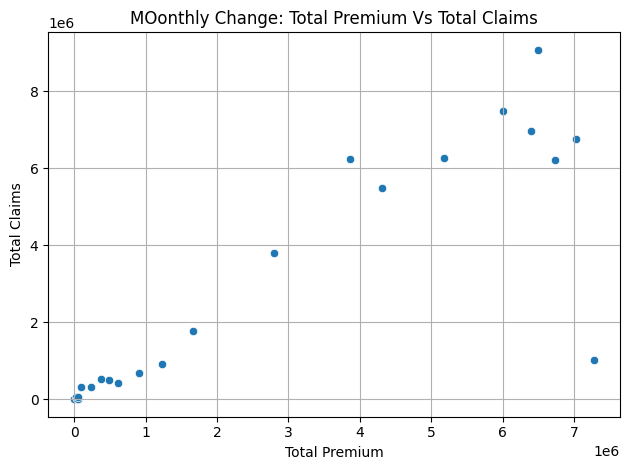

In [ ]:
# Scatter Plot for Total Premium Vs Total Claims

monthly_data = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).to_timestamp()

sns.scatterplot(data=monthly_data, x='TotalPremium', y='TotalClaims')
plt.title('MOonthly Change: Total Premium Vs Total Claims')
plt.xlabel('Total Premium')
plt.ylabel('Total Claims')
plt.grid(True)
plt.tight_layout()
plt.show()


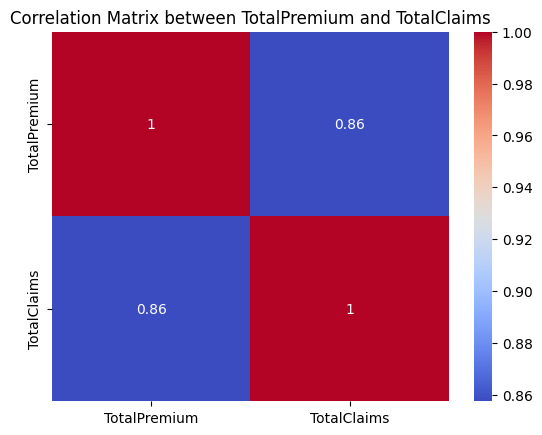

In [ ]:
# Correlation 

corr = monthly_data[['TotalPremium', 'TotalClaims']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix between TotalPremium and TotalClaims')
plt.show()



Data Comparison

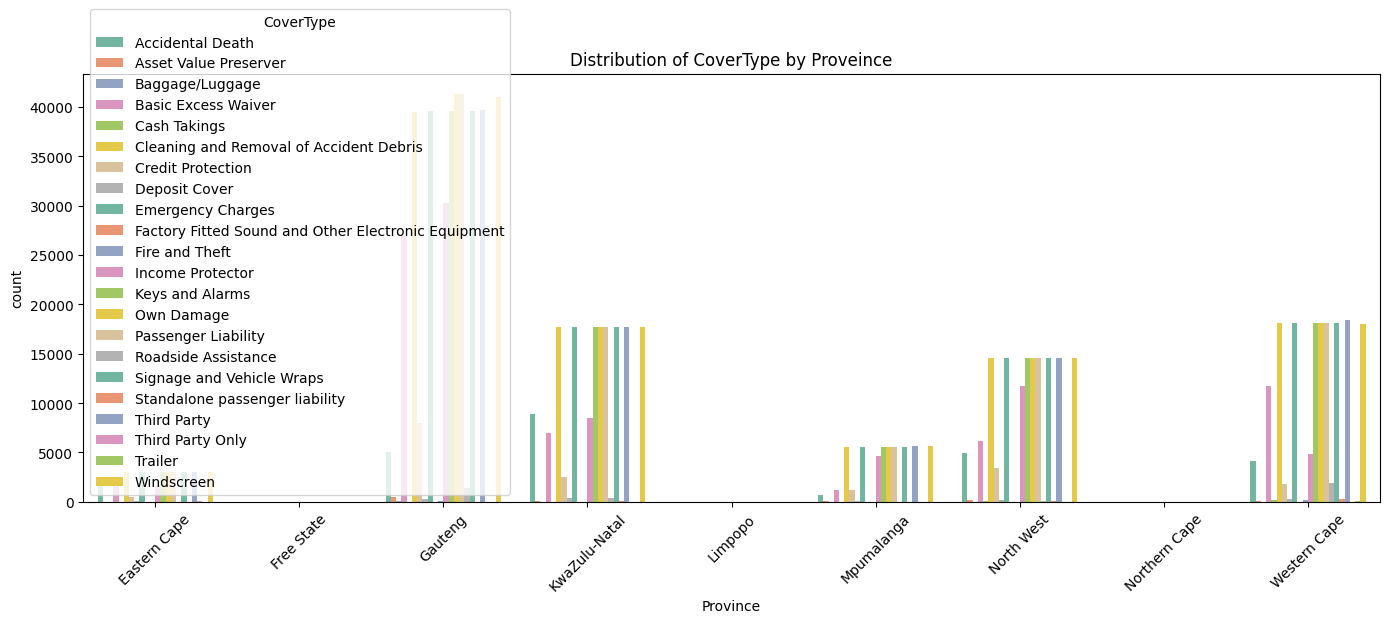

In [71]:
# Covertype per province

top_provinces = df['Province'].value_counts().head(6).index

df_filtered = df[df['Province'].isin(top_provinces)]
plt.figure(figsize=(14,6))
sns.countplot(data=df_filtered, x='Province', hue='CoverType', palette='Set2')
plt.title('Distribution of CoverType by Proveince')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\1271171323.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Province', y='TotalPremium', estimator='mean', ci=None)


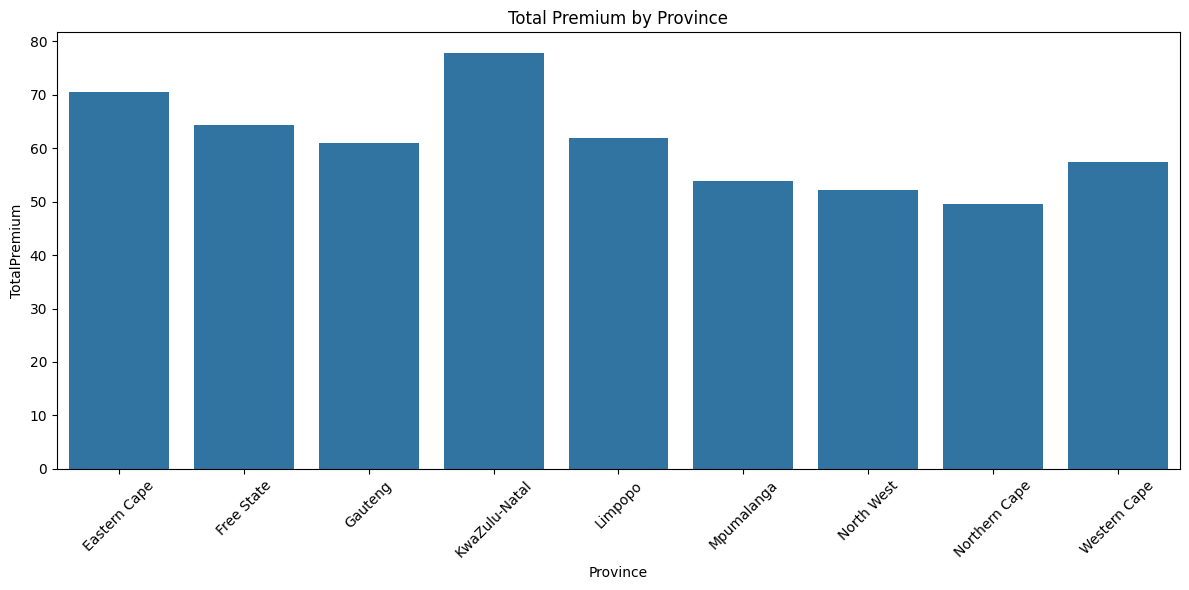

In [76]:
# Average TotalPremium by Province

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Province', y='TotalPremium', estimator='mean', ci=None)
plt.title('Total Premium by Province')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_5520\4059398804.py:13: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


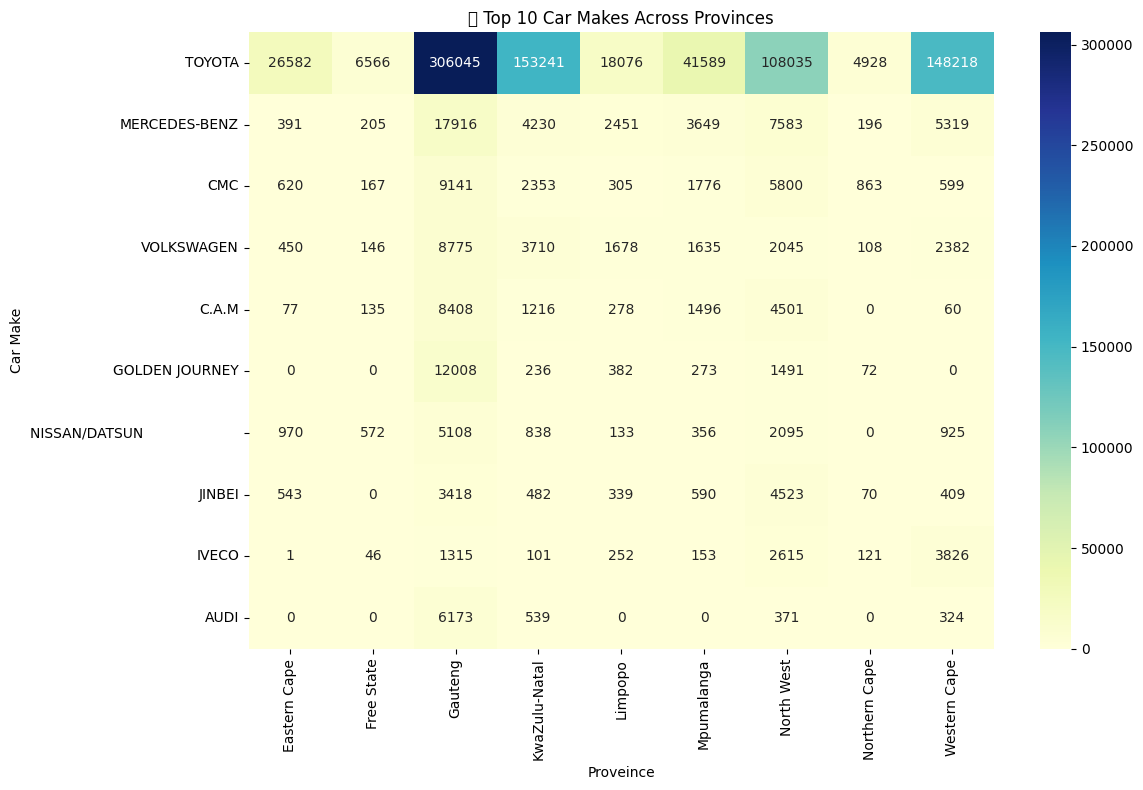

In [78]:
# Popular Vehicle Makes by Province

make_by_province = pd.crosstab(df['make'], df['Province'])

top_makes = df['make'].value_counts().head(10).index
make_by_province = make_by_province.loc[top_makes]

plt.figure(figsize=(12,8))
sns.heatmap(make_by_province, cmap='YlGnBu', annot=True, fmt='d')
plt.title("🚗 Top 10 Car Makes Across Provinces")
plt.xlabel('Proveince')
plt.ylabel('Car Make')
plt.tight_layout()
plt.show()

Outlier Detection

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_6392\3013175975.py:22: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


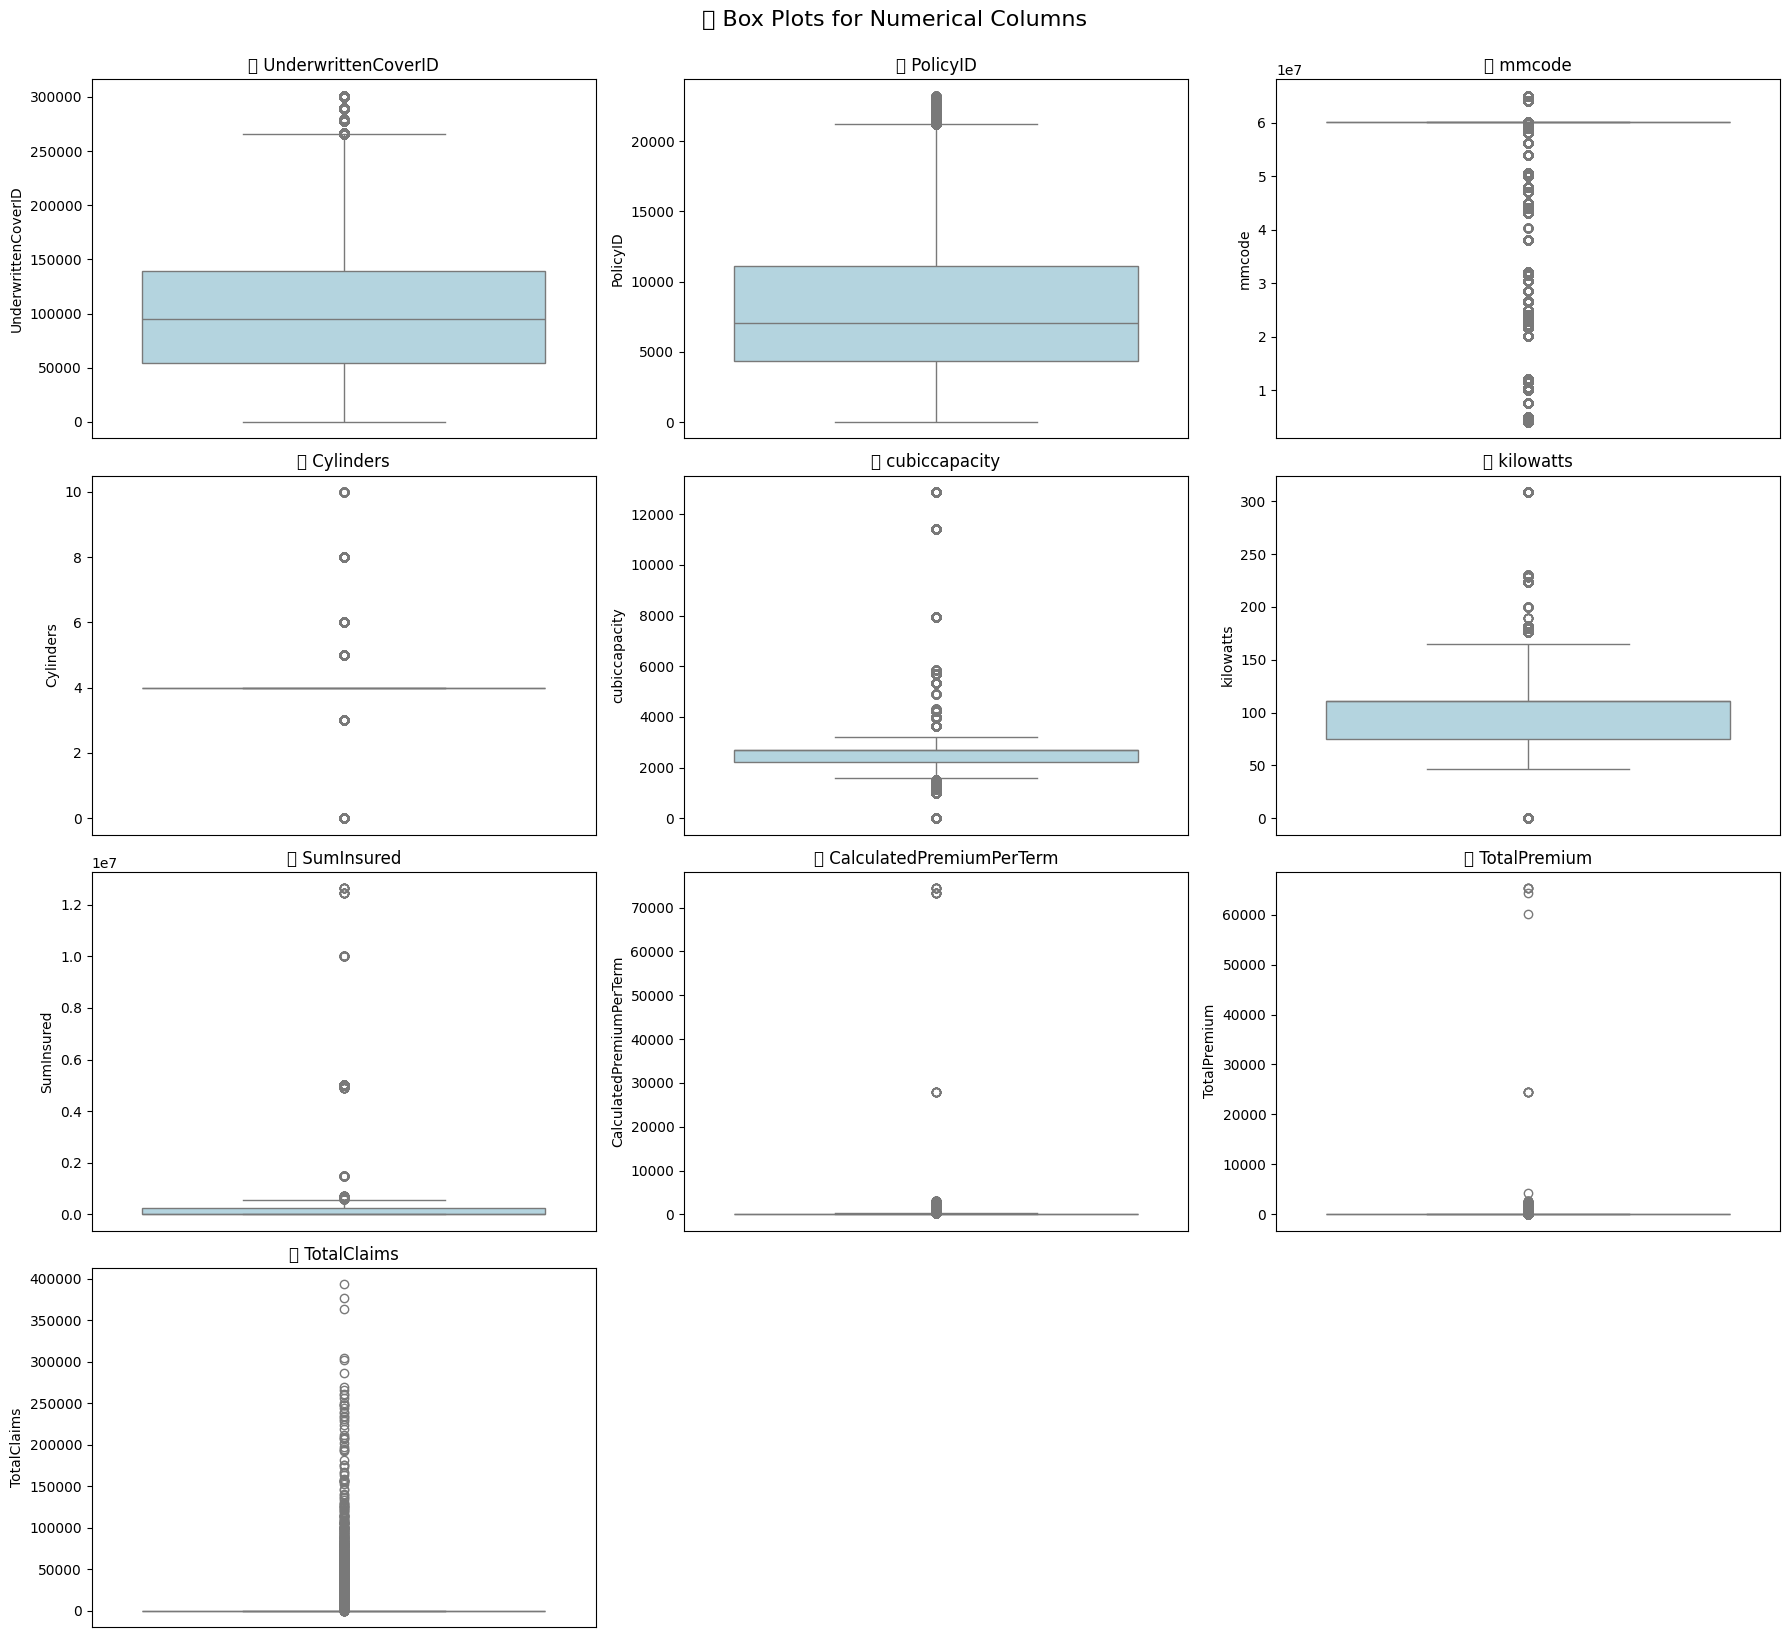

In [ ]:
numeric_cols = df[['UnderwrittenCoverID', 'PolicyID','mmcode', 'Cylinders', 'cubiccapacity', 'kilowatts','SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

# Plot each boxplot
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f"📦 {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Turn off extra subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.suptitle("📦 Box Plots for Numerical Columns", fontsize=16, y=1.02)
plt.show()



Visualization

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_6392\3182668757.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  province_loss = df.groupby('Province')[['TotalClaims', 'TotalPremium']].sum()
C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_6392\3182668757.py:13: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


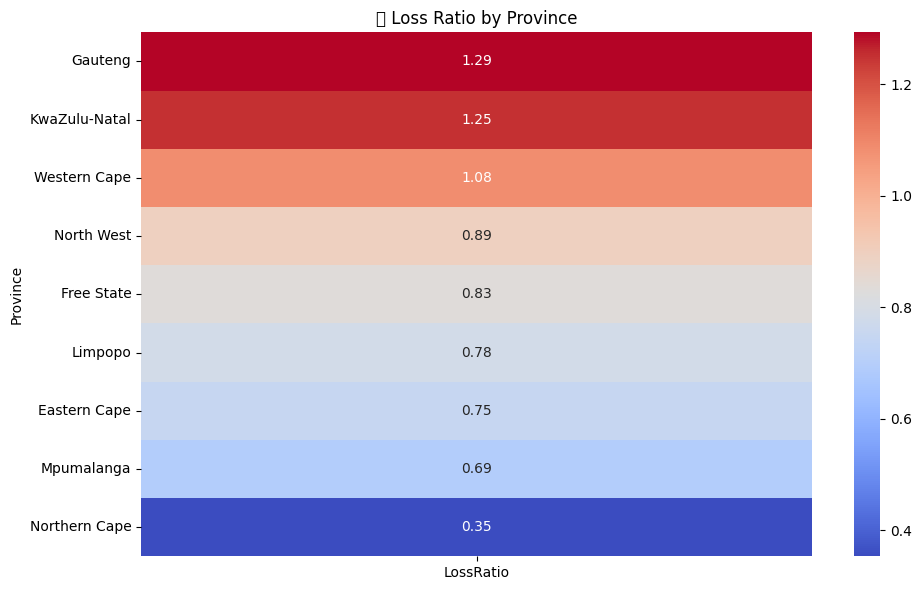

In [ ]:
# Calculate loss ratio
province_loss = df.groupby('Province')[['TotalClaims', 'TotalPremium']].sum()
province_loss['LossRatio'] = province_loss['TotalClaims'] / province_loss['TotalPremium']

plt.figure(figsize=(10, 6))
sns.heatmap(province_loss[['LossRatio']].sort_values('LossRatio', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("🔥 Loss Ratio by Province")
plt.tight_layout()
plt.show()


C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_6392\1823116559.py:7: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


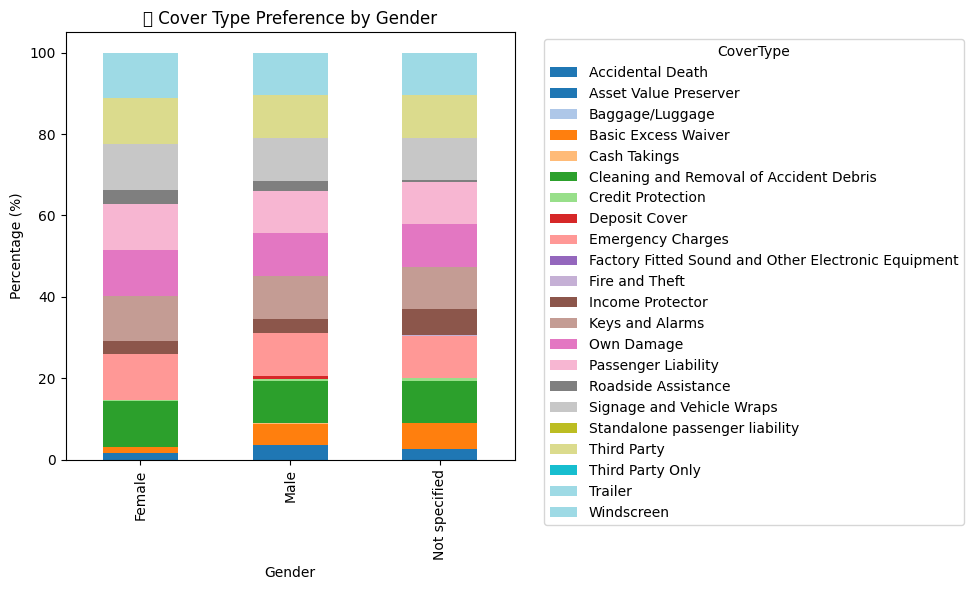

In [12]:
cover_by_gender = pd.crosstab(df['Gender'], df['CoverType'], normalize='index') * 100

cover_by_gender.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.ylabel("Percentage (%)")
plt.title("🛡️ Cover Type Preference by Gender")
plt.legend(title='CoverType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_6392\1624618314.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([df['TransactionMonth'], 'VehicleType'])['TotalClaims']
C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_6392\1624618314.py:22: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


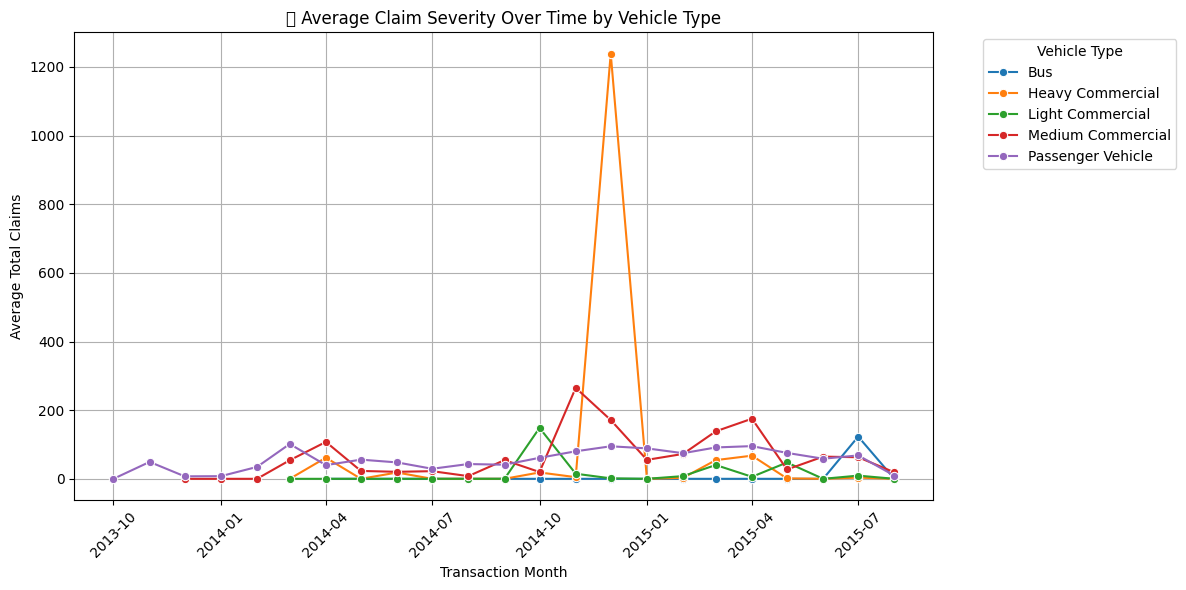

In [ ]:
monthly_claims = (
    df.groupby([df['TransactionMonth'], 'VehicleType'])['TotalClaims'].mean().reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_claims, x='TransactionMonth', y='TotalClaims', hue='VehicleType', marker="o")
plt.title("📅 Average Claim Severity Over Time by Vehicle Type")
plt.ylabel("Average Total Claims")
plt.xlabel("Transaction Month")
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


TASKS

In [37]:
# Overall Loss Ratio
df_valid = df[(df['TotalPremium'] > 0) & (df['TotalClaims'])]
overall_loss_ratio = df_valid['TotalClaims'].sum() / df_valid['TotalPremium'].sum() 

loss_ratio_by_province = df_valid.groupby('Province').apply(
    lambda x:x['TotalClaims'].sum() / x['TotalPremium'].sum()
)

loss_ratio_by_vehicle = df_valid.groupby('VehicleType').apply(
    lambda x:x['TotalClaims'].sum() / x['TotalPremium'].sum()
)

loss_ratio_by_gender = df_valid.groupby('Gender').apply(
    lambda x:x['TotalClaims'].sum() / x['TotalPremium'].sum()
)

print(f"Overall: {overall_loss_ratio}") 
print(f"By Province: {loss_ratio_by_province}") 
print(f"By Vehicle Type: {loss_ratio_by_vehicle}") 
print(f"By Gender: {loss_ratio_by_gender}") 

Overall: 47.31861362458522
By Province: Province
Eastern Cape      87.036359
Free State        89.237599
Gauteng           71.554042
KwaZulu-Natal     59.986486
Limpopo          108.611065
Mpumalanga        98.638474
North West        89.271220
Northern Cape     52.495781
Western Cape      17.707298
dtype: float64
By Vehicle Type: VehicleType
Heavy Commercial     192.420073
Light Commercial      64.649227
Medium Commercial    101.705778
Passenger Vehicle     69.885285
Unknown                1.327652
dtype: float64
By Gender: Gender
Female           66.825585
Male             57.832337
Not specified    46.969965
Unknown          60.424776
dtype: float64


C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_4260\2485284376.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_ratio_by_province = df_valid.groupby('Province').apply(
C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_4260\2485284376.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_ratio_by_vehicle = df_valid.groupby('VehicleType').apply(
C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_4260\2485284

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_4260\2032441731.py:19: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axes[1].set_xlim(0, df['TotalClaims'].quantile(0.99))


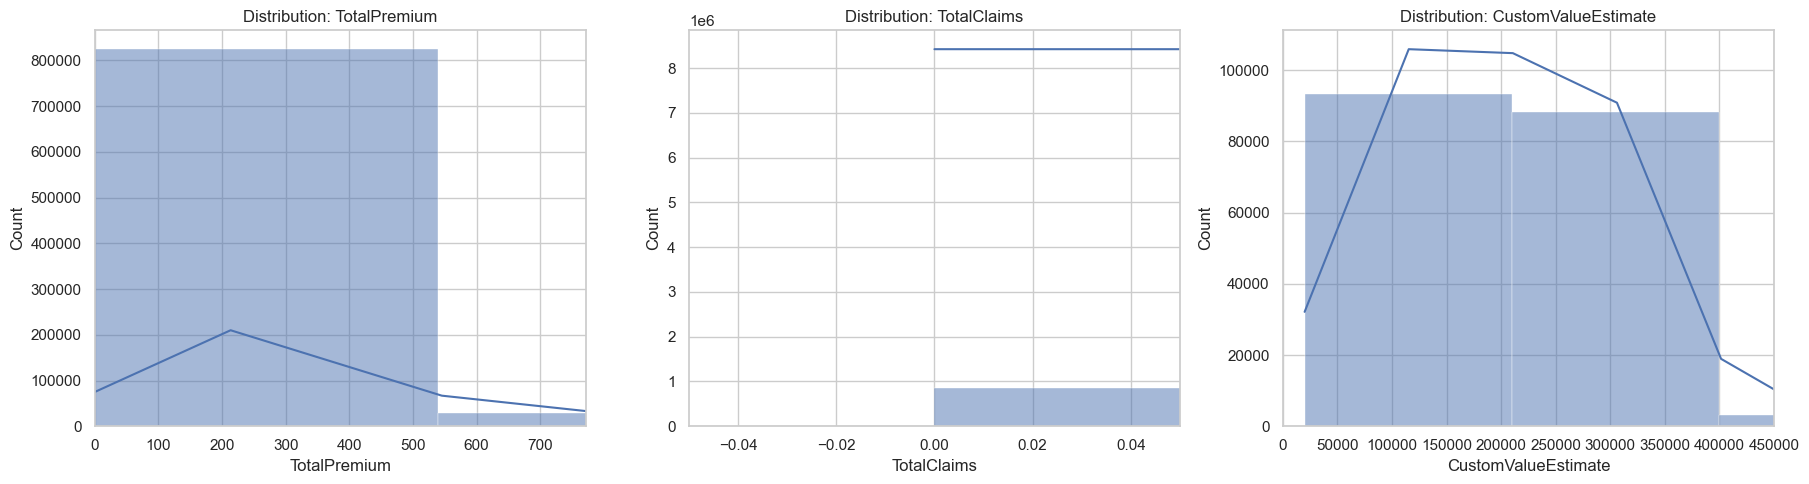

In [ ]:
# Set style
sns.set(style="whitegrid")

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. TotalPremium
sns.histplot(df['TotalPremium'], bins=100, kde=True, ax=axes[0])
axes[0].set_title('Distribution: TotalPremium')
axes[0].set_xlim(0, df['TotalPremium'].quantile(0.99))  # Zoom in to 99th percentile

# 2. TotalClaims
sns.histplot(df['TotalClaims'], bins=100, kde=True, ax=axes[1])
axes[1].set_title('Distribution: TotalClaims')
axes[1].set_xlim(0, df['TotalClaims'].quantile(0.99))

# 3. CustomValueEstimate
sns.histplot(df['CustomValueEstimate'], bins=100, kde=True, ax=axes[2])
axes[2].set_title('Distribution: CustomValueEstimate')
axes[2].set_xlim(0, df['CustomValueEstimate'].quantile(0.99))

plt.tight_layout()
plt.show()


In [39]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column} ➜ Outliers: {len(outliers)} rows ({100 * len(outliers) / len(df):.2f}%)")

detect_outliers('TotalClaims')
detect_outliers('CustomValueEstimate')


TotalClaims ➜ Outliers: 2571 rows (0.30%)
CustomValueEstimate ➜ Outliers: 1298 rows (0.15%)


In [40]:
df['log_TotalClaims'] = df['TotalClaims'].apply(lambda x: np.log1p(x))
df['log_TotalClaims']

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1000093    0.0
1000094    0.0
1000095    0.0
1000096    0.0
1000097    0.0
Name: log_TotalClaims, Length: 854132, dtype: float64

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_4260\1838486183.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_4260\1838486183.py:31: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


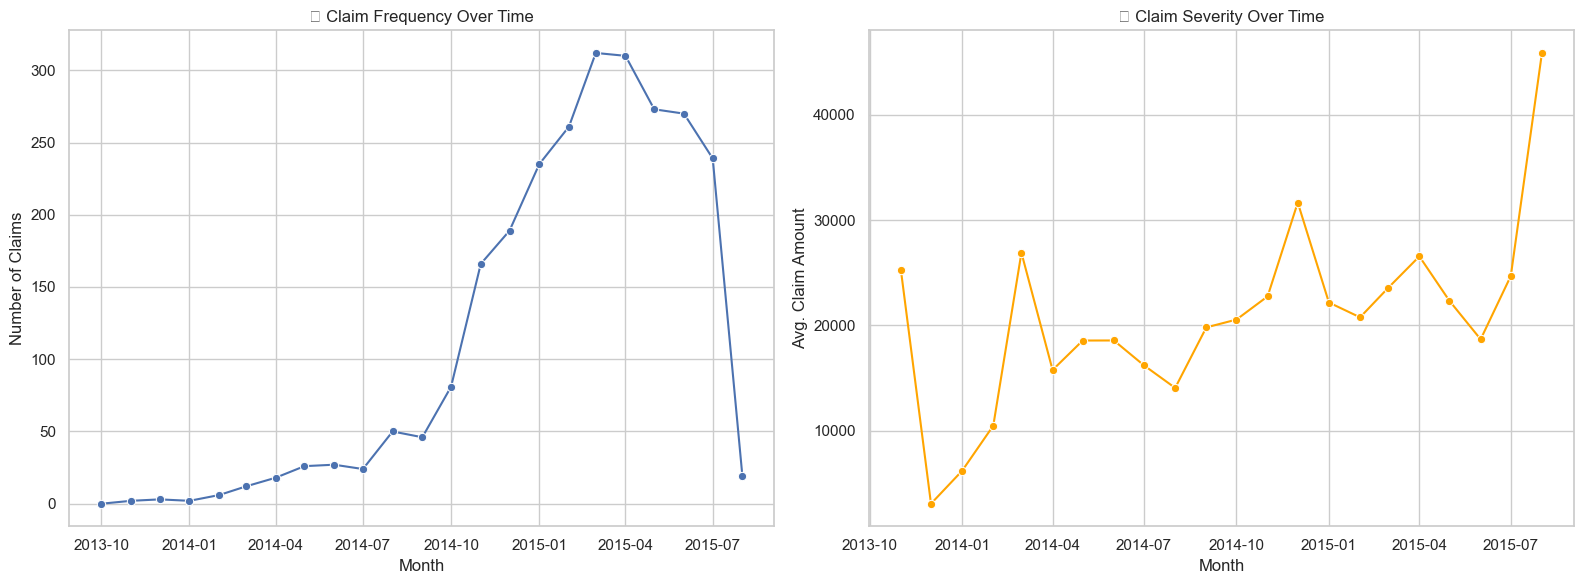

In [ ]:
# Ensure TransactionMonth is datetime
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

# Group by month
monthly_stats = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg(
    claim_count=('TotalClaims', lambda x: (x > 0).sum()),  # Frequency: count of non-zero claims
    total_claims=('TotalClaims', 'sum'),
    avg_severity=('TotalClaims', lambda x: x[x > 0].mean())  # Average per actual claim
).reset_index()

# Convert Period to datetime for plotting
monthly_stats['TransactionMonth'] = monthly_stats['TransactionMonth'].dt.to_timestamp()

# Plot
plt.figure(figsize=(16, 6))

# Frequency
plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_stats, x='TransactionMonth', y='claim_count', marker='o')
plt.title('📈 Claim Frequency Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Claims')

# Severity
plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_stats, x='TransactionMonth', y='avg_severity', marker='o', color='orange')
plt.title('💰 Claim Severity Over Time')
plt.xlabel('Month')
plt.ylabel('Avg. Claim Amount')

plt.tight_layout()
plt.show()


In [ ]:
# Filter rows with valid claim data
df_valid = df[df['TotalClaims'].notnull()]

# Group by vehicle Make and Model, calculate average and total claim amount
vehicle_claim_stats = df_valid.groupby(['make', 'Model']).agg(
    avg_claim=('TotalClaims', 'mean'),
    total_claim=('TotalClaims', 'sum'),
    claim_count=('TotalClaims', 'count')
).reset_index()

# Optional: Filter to models with enough records to be statistically meaningful
vehicle_claim_stats = vehicle_claim_stats[vehicle_claim_stats['claim_count'] > 10]

# Top 10 highest average claim models
highest_avg_claims = vehicle_claim_stats.sort_values(by='avg_claim', ascending=False).head(5)

# Top 10 lowest average claim models
lowest_avg_claims = vehicle_claim_stats.sort_values(by='avg_claim', ascending=True).head(5)

print("🔺 Top 5 Highest Average Claim (Make & Model):")
print(highest_avg_claims[['make', 'Model', 'avg_claim', 'claim_count']])

print("\n🔻 Top 5 Lowest Average Claim (Make & Model):")
print(lowest_avg_claims[['make', 'Model', 'avg_claim', 'claim_count']])

highest_avg_claims_styled = highest_avg_claims.style.set_properties(**{
    'text-align': 'left'
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'left')]
}])

lowest_avg_claims_styled = lowest_avg_claims.style.set_properties(**{
    'text-align': 'left'
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'left')]
}])


🔺 Top 10 Highest Average Claim (Make & Model):
           make                        Model    avg_claim  claim_count
259      TOYOTA  L/CRUISER FJ 4.0 V6 CRUISER  5340.970273           72
69      HYUNDAI       H-1 2.5 CRDI WAGON A/T  4118.181043          108
45         FIAT       DUCATO 2.3 JTD VETRATO  1014.681021           99
294     Unknown                      Unknown  1008.489085          552
331  VOLKSWAGEN            POLO VIVO 1.6 5Dr   827.558882           80

🔻 Top 10 Lowest Average Claim (Make & Model):
           make                           Model  avg_claim  claim_count
14          BMW                     318iS (E36)        0.0           96
10         AUDI       A5 SPRTBACK 2.0 TDI MULTI        0.0          192
6          AUDI  A4 2.0 TDI AMBITION 125KW (B8)        0.0          249
330  VOLKSWAGEN     POLO VIVO 1.4 TRENDLINE 5Dr        0.0           72
329  VOLKSWAGEN            POLO CLASSIC 1.6 Lux        0.0           80


In [65]:
(df['TotalClaims'] < 0).sum()

np.int64(0)